# Cascade Variants — Scaling with ALSSM Order N [ex133.2]

Sweeps **polynomial degree** (poly_degree = 1 … 7, N = 2 … 8) to show how the two cascade
variants from [ex133.1](example-ex133.1-cascade-variants.ipynb) scale with the ALSSM state-space dimension.
All cascade setup (`build_cascade_inputs`, variant closures) follows **[ex133.1](example-ex133.1-cascade-variants.ipynb)**. Signal length
and segment are fixed.

| Axis | Value |
|------|-------|
| Signal length K | 1 000 000 (fixed) |
| Segment | `a=−21, b=−1, direction=FW, g=100` |
| Swept parameter | `poly_degree` ∈ {1, 2, 3, 4, 5, 6, 7} → **N** ∈ {2, 3, 4, 5, 6, 7, 8} |

**Two variants** (identical to ex133.1):

| # | Label | xi0 order |
|---|-------|:---------:|
| 1 | Original | C (default) |
| 2 | F-order | F |

In-place variants are not applicable because `xi0` must be larger than `xi` for signal shifting.

**Why operations scale with N**:
- `lfilter` calls: N (one per dimension)
- coupling `einsum` calls: N − 1, each of cost O(K·N) → total O(K·N²)
- write bytes (both scratch variants): 3·K·N·8 bytes

**Series:**
- **[ex133.0](example-ex133.0-profile.ipynb)** — baseline profiling, hotspot identification
- **[ex133.1](example-ex133.1-cascade-variants.ipynb)** — same two variants at the fixed N=2 production model
- **[ex133.2](example-ex133.2-profile-higher-order.ipynb)** ← this notebook — N sweep
- **[ex133.3](example-ex133.3-applied.ipynb)** — before/after pipeline benchmark of the applied optimization


In [1]:
import io, time, tracemalloc
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, matrix_power as _mpow
from scipy.signal import lfilter as _scipy_lf
import lmlib as lm

lm.WARNING_NOT_STEADY_STATE = False

## Configuration

In [2]:
K        = 1_000_000          # fixed signal length
N_time   = 20                  # timing repetitions per (variant, N)
N_mem    = 10                  # tracemalloc repetitions

# Segment shared across all orders
seg_l = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)

poly_degrees = [1, 2, 3, 4, 5, 6, 7]   # N = poly_degree + 1
N_orders     = [p + 1 for p in poly_degrees]

bar_cols = [lm.NORD['blue'], lm.NORD['green']]
var_labels = [
    'Before (C-order xi0)',
    'After  (F-order xi0)',
]
_ord = ['C', 'F']

print(f"K={K:,}, poly_degrees={poly_degrees}")
print(f"N_orders={N_orders}")


K=1,000,000, poly_degrees=[1, 2, 3, 4, 5, 6, 7]
N_orders=[2, 3, 4, 5, 6, 7, 8]


## Helper: build variant closures

For each ALSSM order N, `make_variants(poly_degree, seg, K)` returns two closures that call
the actual **before** (`ex133_before_impl.lfilter_forward_cascade_xi`) and **after**
(`rec_lfilter.lfilter_forward_cascade_xi`) implementations with pre-captured `A`, `C`, `y`, `sw`.


In [3]:
import importlib
import lmlib.statespace.backends.rec_lfilter as _rlf_mod
import ex133_before_impl as _before_mod
importlib.reload(_before_mod)


def make_variants(poly_degree, seg, K):
    """Return ([before_fn, after_fn], N) for a given poly_degree.

    Each closure calls the actual module implementation with pre-captured
    A, C, y, sw — signature: vfn(xi).
    """
    alssm = lm.AlssmPoly(poly_degree=poly_degree)
    A   = np.atleast_2d(alssm.A)
    C   = np.atleast_2d(alssm.C)
    N   = A.shape[1]
    rng = np.random.default_rng(42)
    y   = rng.standard_normal((K, 1))  # (K, 1) — Q=1 observation, matches pipeline shape
    sw  = np.ones(K)
    args = (A, C, seg.a, seg.b, seg.delta, seg.gamma, y, sw, 1.0)

    def v_before(xi):
        """Before: C-order xi0 = np.zeros(xi.shape), xi += xi0."""
        _before_mod.lfilter_forward_cascade_xi(xi, *args)

    def v_after(xi):
        """After: F-order xi0 = np.zeros((K+δ, N), order='F'), xi += xi0[slice]."""
        _rlf_mod.lfilter_forward_cascade_xi(xi, *args)

    return [v_before, v_after], N


print("make_variants defined.")

# Quick sanity check at N=2
_vfns_test, _N_test = make_variants(1, seg_l, 1_000)
_xi_test = np.zeros((1_000, _N_test), order='F')
_vfns_test[0](_xi_test)
print(f"Sanity check passed: xi.shape={_xi_test.shape}, max={np.abs(_xi_test).max():.3f}")


make_variants defined.
Sanity check passed: xi.shape=(1000, 2), max=152.005


## Correctness check

Compare **before** vs **after** at each polynomial degree — both must agree to within floating-point tolerance.

Tiny numeric discrepancies at large N are expected: different write order changes floating-point rounding.
These are well within `np.allclose` relative tolerance.


In [4]:
K_check = 3_000

print(f"{'pd':>3}  {'N':>2}  {'max_diff':>12}  {'allclose':>9}")
print("─" * 32)

for p in poly_degrees:
    vfns_c, N = make_variants(p, seg_l, K_check)
    xi_b = np.zeros((K_check, N), order='C')
    xi_a = np.zeros((K_check, N), order='F')
    vfns_c[0](xi_b)   # before
    vfns_c[1](xi_a)   # after
    err = np.abs(xi_b - xi_a).max()
    ok  = np.allclose(xi_b, xi_a)
    print(f"{p:>3}  {N:>2}  {err:>12.2e}  {'OK' if ok else 'FAIL':>9}")

print("\nAll OK = before and after produce numerically identical results.")


 pd   N      max_diff   allclose
────────────────────────────────
  1   2      0.00e+00         OK
  2   3      0.00e+00         OK
  3   4      0.00e+00         OK
  4   5      0.00e+00         OK
  5   6      0.00e+00         OK
  6   7      0.00e+00         OK
  7   8      0.00e+00         OK

All OK = before and after produce numerically identical results.


## Wall-time sweep

For each `poly_degree` (= N − 1) and each variant, run N_time timed iterations on the same
pre-built `y_diff_master`.

In [5]:
time_results = {}

for p in poly_degrees:
    vfns, N = make_variants(p, seg_l, K)
    time_results[N] = []
    for vi, (vfn, order) in enumerate(zip(vfns, _ord)):
        _xi_t = np.zeros((K, N), order=order)
        ts = []
        for _ in range(N_time):
            _xi_t[:] = 0
            t0 = time.perf_counter()
            vfn(_xi_t)
            ts.append((time.perf_counter() - t0) * 1e3)
        time_results[N].append(np.array(ts))

    medians = [np.median(time_results[N][vi]) for vi in range(2)]
    print(f"N={N}:  " + "  ".join(f"{var_labels[vi][:12]}={medians[vi]:.1f}ms" for vi in range(2)))

print("\nTime sweep done.")


N=2:  Before (C-or=52.5ms  After  (F-or=45.3ms
N=3:  Before (C-or=77.8ms  After  (F-or=63.5ms
N=4:  Before (C-or=97.3ms  After  (F-or=83.8ms
N=5:  Before (C-or=136.1ms  After  (F-or=117.0ms
N=6:  Before (C-or=170.8ms  After  (F-or=145.4ms
N=7:  Before (C-or=210.5ms  After  (F-or=176.8ms
N=8:  Before (C-or=253.5ms  After  (F-or=208.3ms

Time sweep done.


### Wall-time vs N

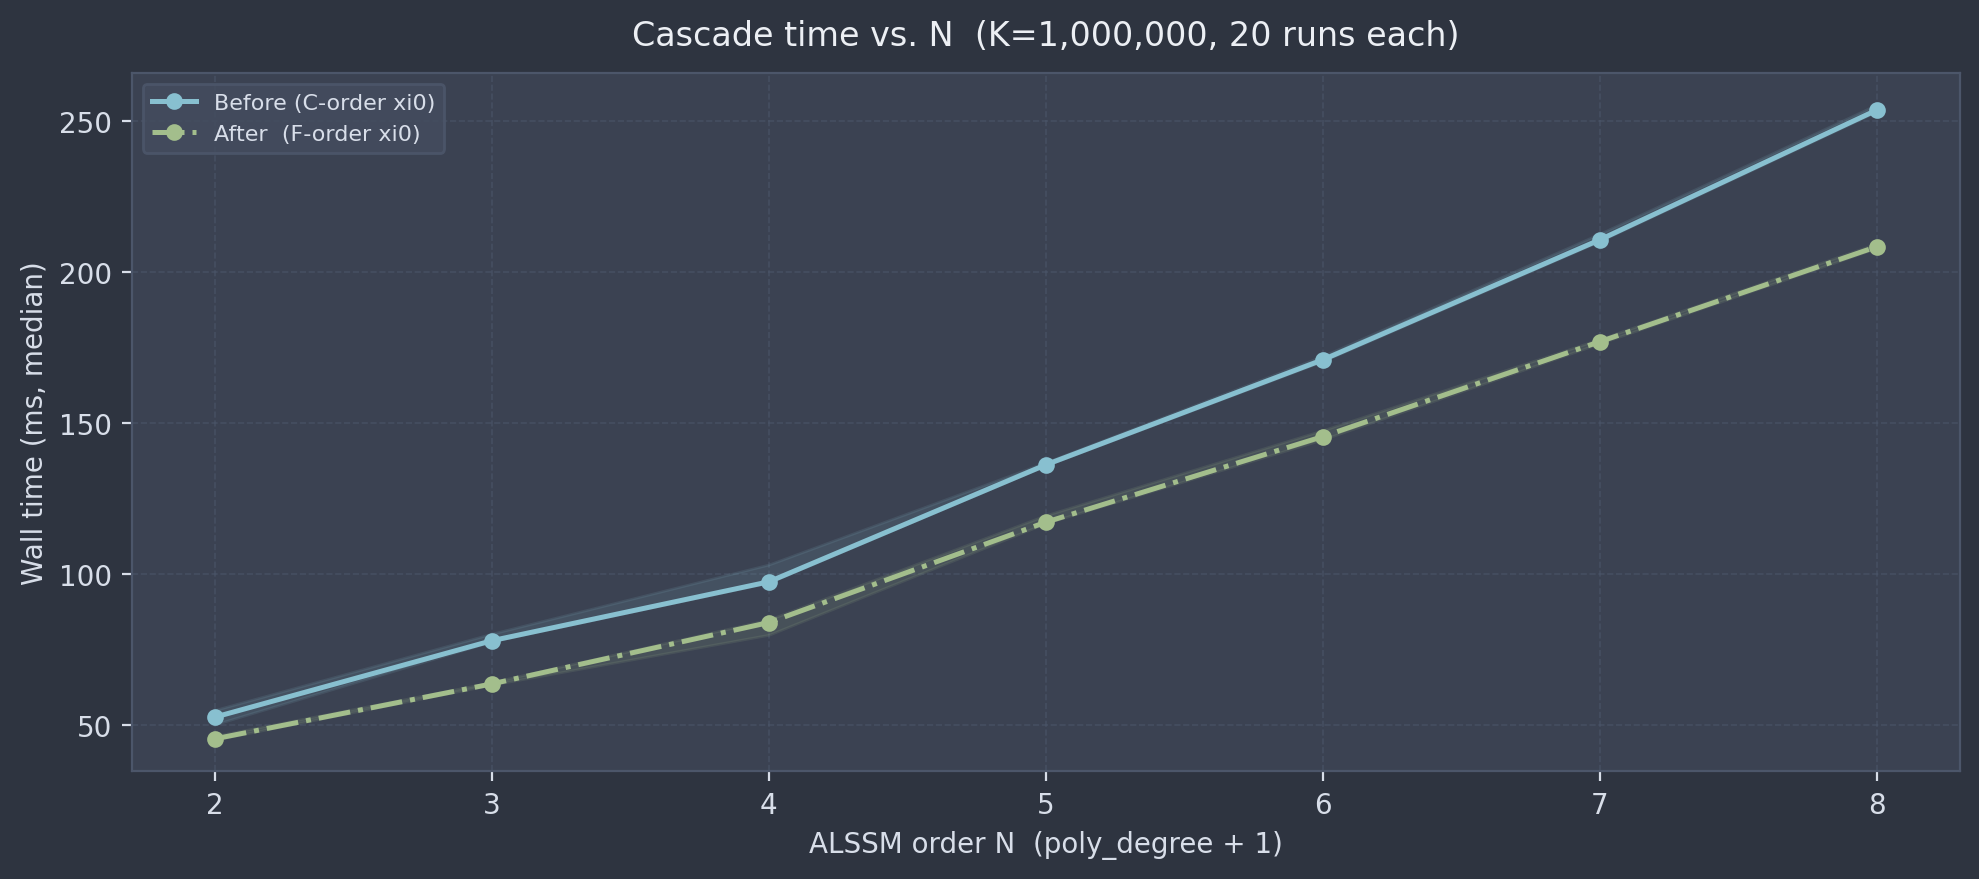

In [6]:
Ns = N_orders

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])
ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

ls = ['-', '-.']
for vi, (vlab, vcol, vls) in enumerate(zip(var_labels, bar_cols, ls)):
    t_med = [np.median(time_results[N][vi]) for N in Ns]
    t_min = [time_results[N][vi].min()      for N in Ns]
    t_max = [time_results[N][vi].max()      for N in Ns]
    ax.plot(Ns, t_med, color=vcol, marker='o', linewidth=1.8, markersize=5,
            linestyle=vls, label=vlab)
    ax.fill_between(Ns, t_min, t_max, color=vcol, alpha=0.12)

ax.set_xlabel('ALSSM order N  (poly_degree + 1)', color=lm.NORD['fg'])
ax.set_ylabel('Wall time (ms, median)', color=lm.NORD['fg'])
ax.set_title(f'Cascade time vs. N  (K={K:,}, {N_time} runs each)',
             color=lm.NORD['white'], pad=10)
ax.set_xticks(Ns)
ax.xaxis.set_tick_params(labelcolor=lm.NORD['fg'])
ax.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
          labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.show()


## Total memory sweep

`tracemalloc` measures the **peak simultaneously-live** heap during a single cascade call.
Here `xi` is allocated **inside** the traced block so the output buffer is counted too.

| Variant | Simultaneous live allocations | Peak formula |
|---------|------------------------------|:-------------|
| Scratch (C / F) | `xi` (output) + `xi0` (scratch) | 2 · K · N · 8 B |
| In-place (C / F) | `xi` (output) + einsum temp `(K-1,)` | K · N · 8 B + (K-1) · 8 B ≈ K·(N+1)·8 B |

Both now scale with N, but scratch allocates **2×** as much as in-place.

In [7]:
mem_results = {}

for p in poly_degrees:
    vfns, N = make_variants(p, seg_l, K)
    mem_results[N] = []
    for vi, (vfn, order) in enumerate(zip(vfns, _ord)):
        peaks = []
        for _ in range(N_mem):
            tracemalloc.start()
            xi = np.zeros((K, N), order=order)  # allocate inside traced region
            vfn(xi)
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            del xi
            peaks.append(peak / 1024**2)
        mem_results[N].append(np.array(peaks))

    meds = [np.median(mem_results[N][vi]) for vi in range(2)]
    print(f"N={N}:  " + "  ".join(f"{var_labels[vi][:12]}={meds[vi]:.1f}MB" for vi in range(2)))

print("\nMemory sweep done.")


N=2:  Before (C-or=76.3MB  After  (F-or=76.3MB
N=3:  Before (C-or=99.2MB  After  (F-or=99.2MB
N=4:  Before (C-or=122.1MB  After  (F-or=122.1MB
N=5:  Before (C-or=145.0MB  After  (F-or=145.0MB
N=6:  Before (C-or=167.9MB  After  (F-or=167.9MB
N=7:  Before (C-or=190.7MB  After  (F-or=190.7MB
N=8:  Before (C-or=213.6MB  After  (F-or=213.6MB

Memory sweep done.


### Peak memory vs N

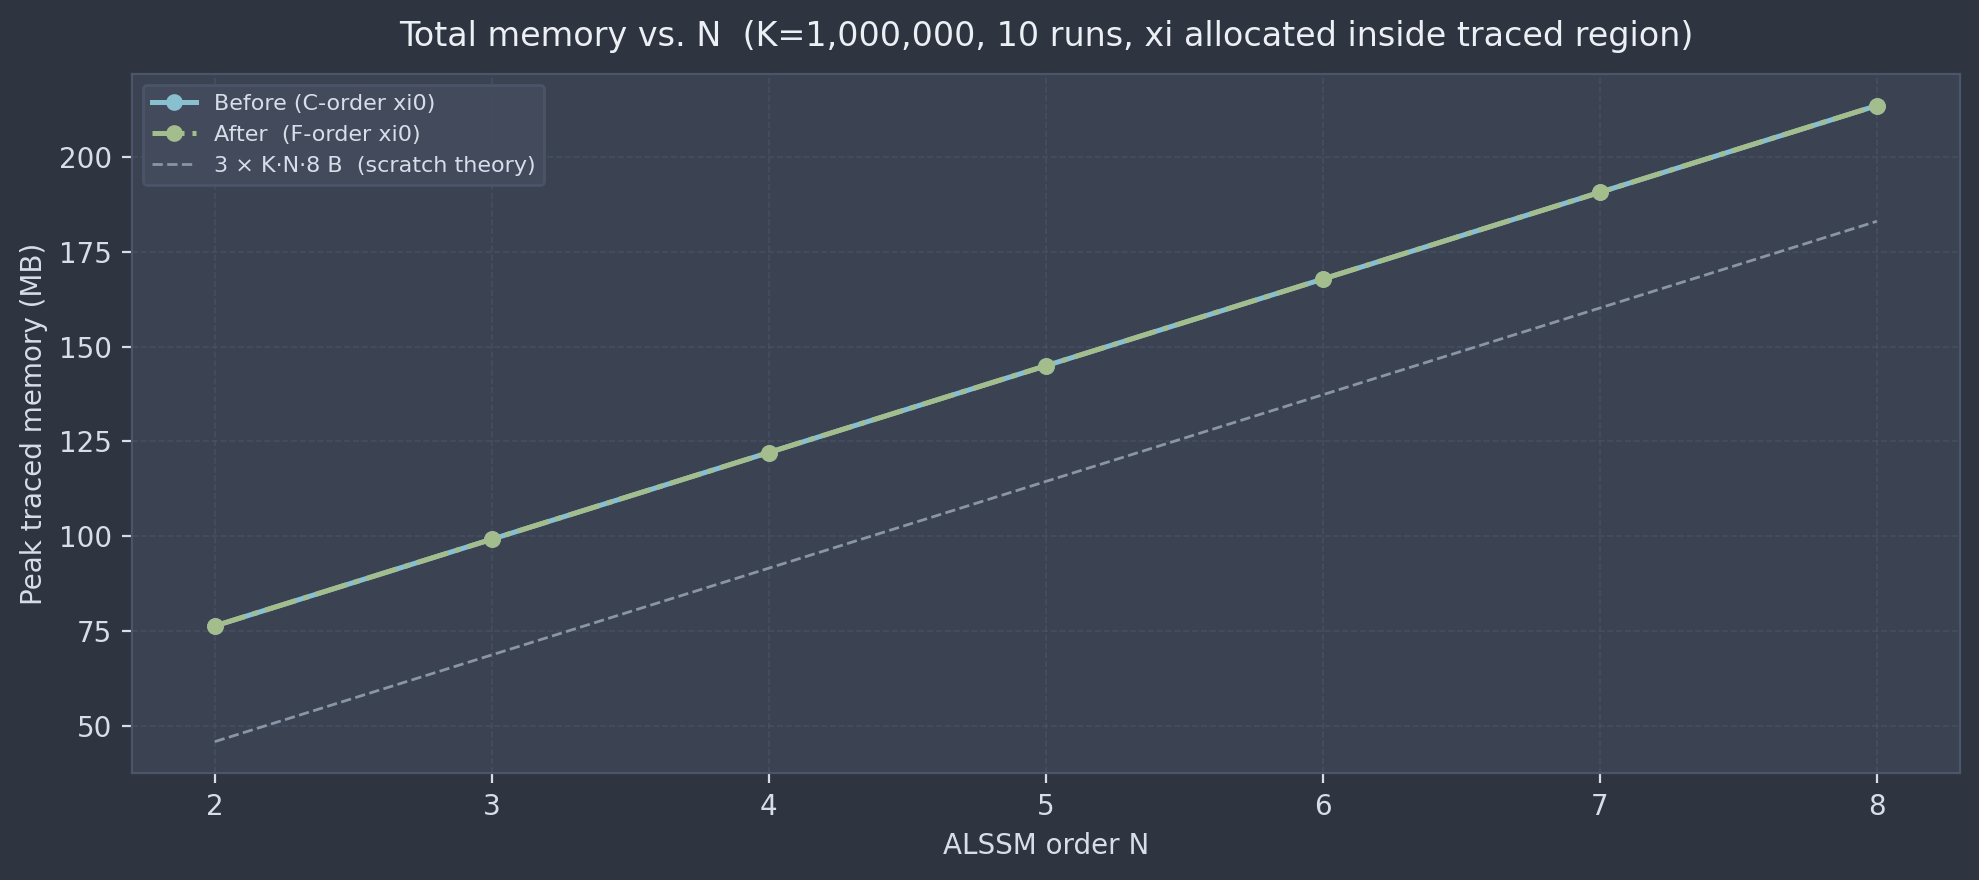

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])
ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

for vi, (vlab, vcol, vls) in enumerate(zip(var_labels, bar_cols, ls)):
    m_med = [np.median(mem_results[N][vi]) for N in Ns]
    m_min = [mem_results[N][vi].min()      for N in Ns]
    m_max = [mem_results[N][vi].max()      for N in Ns]
    ax.plot(Ns, m_med, color=vcol, marker='o', linewidth=1.8, markersize=5,
            linestyle=vls, label=vlab)
    ax.fill_between(Ns, m_min, m_max, color=vcol, alpha=0.12)

# Theoretical reference line: 3 × K·N·8 B (scratch variant: xi + xi0 + add)
_grey = '#8896a8'
xi_3x = [3 * K * N * 8 / 1024**2 for N in Ns]
ax.plot(Ns, xi_3x, color=_grey, linewidth=1.0, linestyle='--', label='3 × K·N·8 B  (scratch theory)')

ax.set_xlabel('ALSSM order N', color=lm.NORD['fg'])
ax.set_ylabel('Peak traced memory (MB)', color=lm.NORD['fg'])
ax.set_title(f'Total memory vs. N  (K={K:,}, {N_mem} runs, xi allocated inside traced region)',
             color=lm.NORD['white'], pad=10)
ax.set_xticks(Ns)
ax.xaxis.set_tick_params(labelcolor=lm.NORD['fg'])
ax.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
          labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.show()


## Operation counts vs N

Analytical counts — no profiling overhead.

Both variants have equal operation counts; the F-order benefit is write locality, not fewer ops.
`xi0` shape differs slightly (before: `(K, N)`, after: `(K+δ, N)` where δ = b−a+1 = 21) — negligible at K=1M.

| Quantity | Formula | Notes |
|----------|---------|-------|
| `lfilter` calls | N | one per cascade dimension |
| `einsum` calls | N − 1 | coupling term, runs from n_=1 |
| `np.zeros` allocs | 1 | both variants allocate xi0 |
| array `+=` | 1 | `xi += xi0` (before) / `xi += xi0[slice]` (after) |
| col write MB | K·N·8 / 2²⁰ | all variants (δ≪K so before ≈ after) |
| xi0 fill MB | K·N·8 / 2²⁰ | same reasoning |
| `+=` dest MB | K·N·8 / 2²⁰ | both variants |
| **total write MB** | 3·K·N·8 / 2²⁰ | identical for both (to within δ/K ≪ 1) |



N=2:
  Variant                                  zeros   lfilter   einsum    add    write MB
  ──────────────────────────────────────────────────────────────────────────────
  Before (C-order xi0)                         1         2        1      1        45.8
  After  (F-order xi0)                         1         2        1      1        45.8

N=8:
  Variant                                  zeros   lfilter   einsum    add    write MB
  ──────────────────────────────────────────────────────────────────────────────
  Before (C-order xi0)                         1         8        7      1       183.1
  After  (F-order xi0)                         1         8        7      1       183.1

δ=21, K=1,000,000: after xi0 is 0.0021% larger — negligible.
F-order speedup is access pattern (contiguous column writes), not fewer ops.


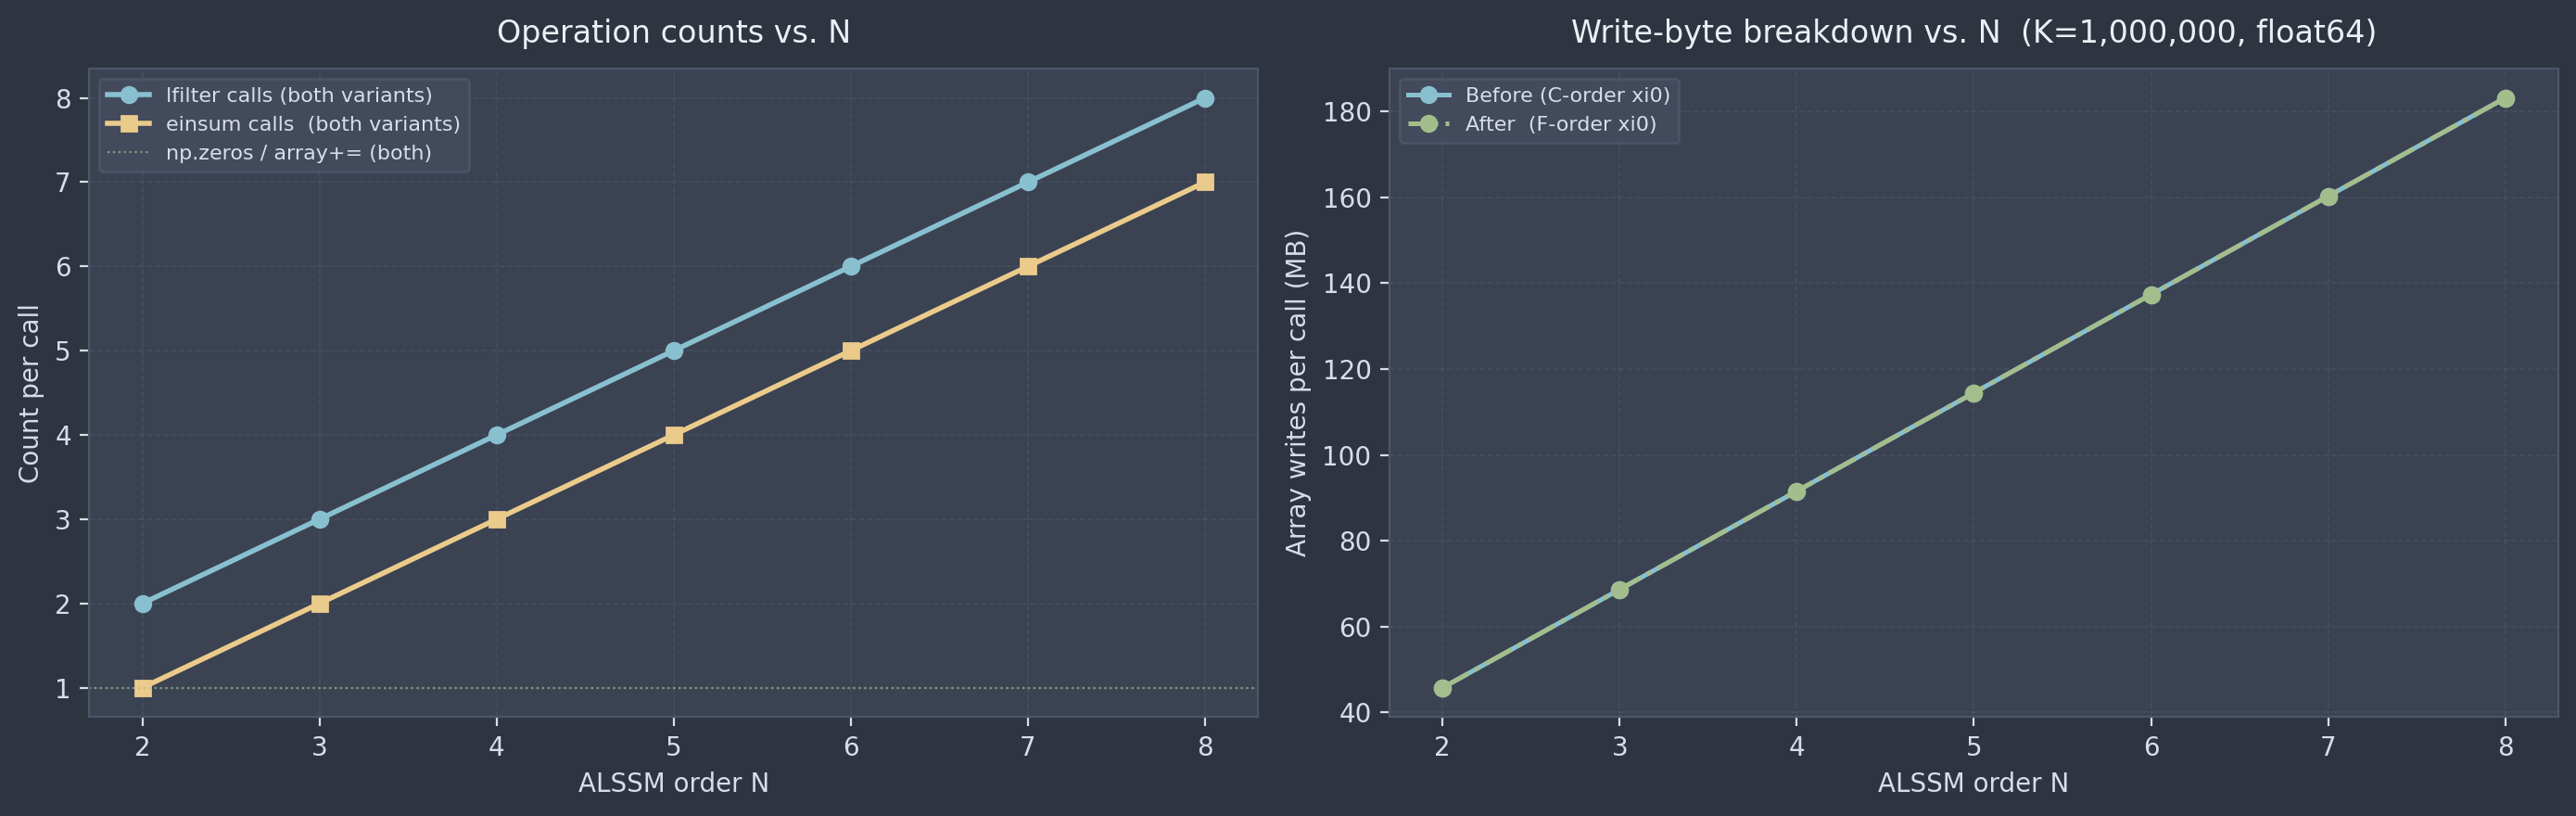

In [9]:
# ── Analytical operation counts ───────────────────────────────────────────────
K_append = int(seg_l.b - seg_l.a + 1)   # δ = 21 for seg_l

ops_N    = {}
writes_N = {}
for N in N_orders:
    col_mb = K * N * 8 / 1024**2
    ops_N[N] = {
        vlab: {
            'zeros_allocs':  1,
            'lfilter_calls': N,
            'einsum_calls':  N - 1,
            'array_add':     1,
        }
        for vlab in var_labels
    }
    writes_N[N] = {
        var_labels[0]: col_mb * 3,               # before: K×N xi0
        var_labels[1]: col_mb * 3 * (1 + K_append / K),   # after: (K+δ)×N xi0, ≈ col_mb*3
    }

# ── Print summary for representative Ns ──────────────────────────────────────
for N in [2, 8]:
    print(f"\nN={N}:")
    print(f"  {'Variant':<38}  {'zeros':>6}  {'lfilter':>8}  {'einsum':>7}  {'add':>5}  {'write MB':>10}")
    print("  " + "─" * 78)
    for vlab in var_labels:
        o = ops_N[N][vlab]
        print(f"  {vlab:<38}  {o['zeros_allocs']:>6}  {o['lfilter_calls']:>8}  "
              f"{o['einsum_calls']:>7}  {o['array_add']:>5}  {writes_N[N][vlab]:>10.1f}")

print(f"\nδ={K_append}, K={K:,}: after xi0 is {K_append/K*100:.4f}% larger — negligible.")
print("F-order speedup is access pattern (contiguous column writes), not fewer ops.")

# ── Figure: 2 panels — op counts vs N, write MB vs N ─────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])

for ax in (ax_l, ax_r):
    ax.set_facecolor(lm.NORD['bg2'])
    for sp in ax.spines.values():
        sp.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_xticks(N_orders)
    ax.xaxis.set_tick_params(labelcolor=lm.NORD['fg'])
    ax.set_xlabel('ALSSM order N', color=lm.NORD['fg'])

# Left: lfilter and einsum counts (same for both variants — show once)
lf_counts = [ops_N[N][var_labels[0]]['lfilter_calls'] for N in N_orders]  # = N
es_counts = [ops_N[N][var_labels[0]]['einsum_calls']  for N in N_orders]  # = N-1
ax_l.plot(N_orders, lf_counts, color=lm.NORD['blue'],   marker='o', linewidth=2, label='lfilter calls (both variants)')
ax_l.plot(N_orders, es_counts, color=lm.NORD['yellow'],  marker='s', linewidth=2, label='einsum calls  (both variants)')
ax_l.axhline(1, color=lm.NORD['green'], linewidth=0.8, linestyle=':', alpha=0.7, label='np.zeros / array+= (both)')

ax_l.set_ylabel('Count per call', color=lm.NORD['fg'])
ax_l.set_title('Operation counts vs. N', color=lm.NORD['white'], pad=10)
ax_l.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
            labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

# Right: write MB per variant (overlapping — before ≈ after)
ls = ['-', '-.']
for vi, (vlab, vcol, vls_) in enumerate(zip(var_labels, bar_cols, ls)):
    wMB = [writes_N[N][vlab] for N in N_orders]
    ax_r.plot(N_orders, wMB, color=vcol, marker='o', linewidth=1.8, linestyle=vls_, label=vlab)

ax_r.set_ylabel('Array writes per call (MB)', color=lm.NORD['fg'])
ax_r.set_title(f'Write-byte breakdown vs. N  (K={K:,}, float64)', color=lm.NORD['white'], pad=10)
ax_r.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
            labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

fig.tight_layout()
plt.show()


## Summary

Calls the actual **before** (`ex133_before_impl`) and **after** (`rec_lfilter`, production) implementations.

| Observation | Explanation |
|-------------|-------------|
| Wall time grows super-linearly with N | The coupling einsum dominates at large N: O(K·N²) total vs O(K·N) for lfilter |
| F-order advantage is largest at small N | At large N the einsum (order-independent) dominates over column-write locality |
| Both variants have equal operation counts | The F-order speedup is purely from contiguous column writes into xi0 |
| After xi0 is slightly larger (K+δ vs K) | δ=21 ≪ K=1M — negligible memory/time difference |

See [ex133.1](example-ex133.1-cascade-variants.ipynb) for the single-order (N=2) benchmark,
and [ex133.3](example-ex133.3-applied.ipynb) for the full pipeline measurement.
